# OECD FDI Income: Pairwise Numeric Dependence

This notebook evaluates pairwise dependence among the numeric variables while keeping the project's variable-role definitions fixed.

- `TIME_PERIOD` is treated as a discrete temporal variable.
- `OBS_VALUE_NUM` is treated as the main continuous quantitative variable.
- Pearson and Spearman correlations are compared to judge whether a normality-based continuation remains practically acceptable.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', context='talk')
ALPHA = 0.05


C:\Users\Yusuf\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
project_root = Path.cwd()
if not (project_root / 'data').exists():
    project_root = project_root.parent

data_path = project_root / 'data' / 'processed' / 'OECD_FDI_Except_Pointless.csv'
df = pd.read_csv(data_path, sep=';', encoding='latin1', engine='python', on_bad_lines='skip')
df['OBS_VALUE_NUM'] = pd.to_numeric(
    df['OBS_VALUE'].astype(str).str.replace('.', '', regex=False),
    errors='coerce'
)

numeric_df = df[['TIME_PERIOD', 'OBS_VALUE_NUM']].dropna().copy()
display(Markdown(f'**Rows used in pairwise numeric analysis:** {numeric_df.shape[0]:,}'))
numeric_df.head()


**Rows used in pairwise numeric analysis:** 7,407

,TIME_PERIOD,OBS_VALUE_NUM
1,2023,1.940070e+13
2,2023,2.001860e+13
3,2024,9.733939e+13
10,2024,2.210346e+13
11,2024,2.982317e+13


## Correlation Estimates

Pearson measures linear association under stronger distributional assumptions, whereas Spearman measures monotonic association using ranks. If the two coefficients are very close, it is usually a sign that the dependence structure is not being driven by severe nonlinearity or rank-order instability.


In [3]:
pearson_r, pearson_p = stats.pearsonr(numeric_df['TIME_PERIOD'], numeric_df['OBS_VALUE_NUM'])
spearman_r, spearman_p = stats.spearmanr(numeric_df['TIME_PERIOD'], numeric_df['OBS_VALUE_NUM'])
difference = abs(pearson_r - spearman_r)

corr_results = pd.DataFrame([
    {'method': 'Pearson', 'coefficient': pearson_r, 'p_value': pearson_p},
    {'method': 'Spearman', 'coefficient': spearman_r, 'p_value': spearman_p},
    {'method': 'Absolute difference', 'coefficient': difference, 'p_value': np.nan},
])
corr_results.round(6)


,method,coefficient,p_value
0,Pearson,-0.016506,0.155477
1,Spearman,-0.031270,0.007115
2,Absolute difference,0.014764,NaN


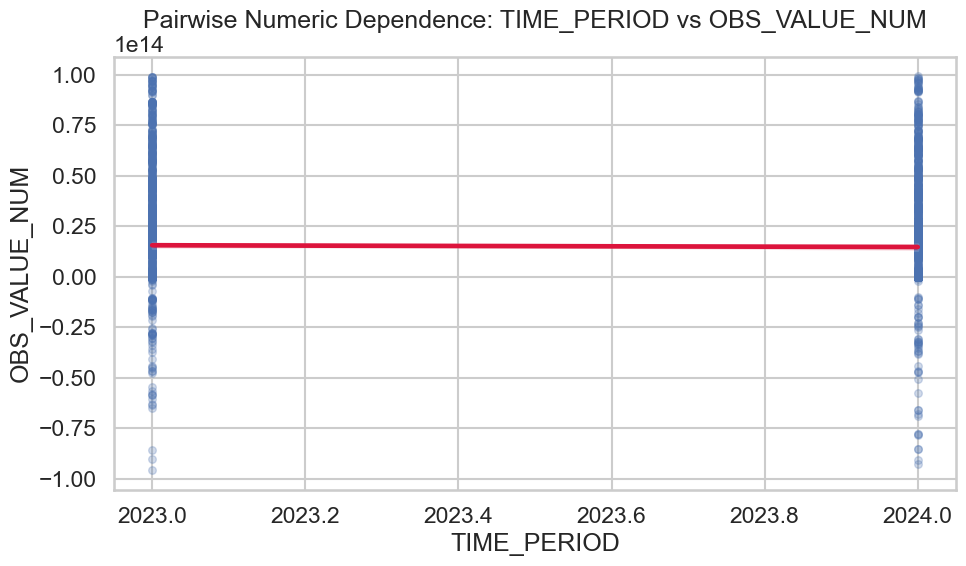

In [4]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=numeric_df.sample(min(2500, len(numeric_df)), random_state=42),
    x='TIME_PERIOD',
    y='OBS_VALUE_NUM',
    scatter_kws={'alpha': 0.25, 's': 30},
    line_kws={'color': 'crimson'}
)
plt.title('Pairwise Numeric Dependence: TIME_PERIOD vs OBS_VALUE_NUM')
plt.xlabel('TIME_PERIOD')
plt.ylabel('OBS_VALUE_NUM')
plt.tight_layout()
plt.show()


## Interpretation


In [5]:
if difference < 0.05:
    interpretation = (
        f"Pearson and Spearman are very close (absolute difference = {difference:.4f}). "
        "This suggests that the dependence pattern is weak and that the rank-based and linear views of association "
        "tell essentially the same story. Therefore, if the remaining assumptions are not seriously violated, "
        "continuing with a normality-based interpretation is defensible in practice."
    )
else:
    interpretation = (
        f"Pearson and Spearman differ meaningfully (absolute difference = {difference:.4f}). "
        "This suggests that the dependence structure may be sensitive to non-normality, nonlinearity, or outliers, "
        "so a strict normality-based continuation should be justified cautiously."
    )

display(Markdown('### Comment\n\n' + interpretation))


### Comment

Pearson and Spearman are very close (absolute difference = 0.0148). This suggests that the dependence pattern is weak and that the rank-based and linear views of association tell essentially the same story. Therefore, if the remaining assumptions are not seriously violated, continuing with a normality-based interpretation is defensible in practice.